In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [22]:
# ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

mpl.rcParams['xtick.labelsize']=5
mpl.rcParams['ytick.labelsize']=5

mpl.rcParams['axes.titlesize']=7
mpl.rcParams['axes.labelsize']=6
mpl.rcParams["axes.titlepad"]=12
mpl.rcParams['axes.linewidth']=1
mpl.rcParams["axes.spines.right"]=False
mpl.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

In [2]:
def decide_pval_text(pval,palpha):

    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt
    
def add_pair_to_plot_box(df,stat_base,ax,pcol,scol,startx,dotdist,errdist,psdist,whiskpos,ptxt):

    # -- PARTNER --
    statkey = f'{stat_base}_partner'
    tcol = pcol

    max1 = np.max(df[statkey])
    
    # plot partner dots
    ax.plot(np.zeros(df.shape[0])+startx+dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot partner boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(df[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(df[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- STRANGER --    
    statkey = f'{stat_base}_stranger'
    tcol = scol

    max2 = np.max(df[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(df.shape[0])+startx+psdist-dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(df[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(df[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)
    
    # plot pair lines
    for idx in df.index: ax.plot([startx+dotdist,startx+psdist-dotdist], df.loc[idx,['fraction_partner','fraction_stranger']], 
                                 color = 'k', linewidth = 0.5, linestyle = '-', zorder=3)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = np.max([max1,max2]) + ppad*np.max([max1,max2]), ppad
    px1 = startx
    px2 = startx+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

In [3]:
# ----- SET GLOBAL PARAMETERS -----

# matplotlib plotting defaults
mpl.rcParams['lines.linewidth'] = 2

mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 6

mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams['svg.fonttype'] = 'none'

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

partnercol = np.array([93,57,148])/256
strangercol = np.array([186,186,186])/256

# stats and plotting params
# dotadj = -0.5 # offset for dots from boxplot position

# outlier flier marker properties
# fmrkr = 'x'
# fmrkrsz = 4

figsz = (2,2) # total size of figure
boxalpha = 0.5 # transparency for boxplot face color

boxlw = 1 # boxplot linewidth
medlw = 1.5 # median linewidth
bwidth = 0.9 # box width
caps = False # don't put caps on the error bars

ppad = 0.085 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
pcol = 'k' # color for pvalue bracket
palpha = 0.05 # threshold for significance

ci = 0.95 # normal data box plot confidence interval

# parameters for naive choice index plots
xt = 0.3 # x adjustment for jitter
jitter = 0.2 # jitter value
jitpad = jitter*4 # how much x axis padding to have around the jitter value

whiskspacer = 0.15
whiskpos = -whiskspacer

# data management
na_column = "Unknown_sec"

In [4]:
# ----- LOAD DATA -----
data = pd.read_csv(os.path.join('..','all_annotations.csv'))
data = data.drop(labels=['Unnamed: 0','id'],axis=1)
data.head()

# ----- FILTER TO PPT DATA -----
allppt = data[data['assay']=='PPT'].copy().reset_index()
print(np.unique(allppt.behavior))

# ----- CALCULATE PARTNER/STRANGER CHAMBER TIMES -----
assaydur = 3*60*60 # length of PPT in seconds

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors to combine for total chamber time
partnerBehavs = ['Huddle Partner','Interact Partner','Partner']
strangerBehavs = ['Huddle Stranger','Interact Stranger','Stranger']

# combine partner oriented behaviors into one partner time total
partnercomponents = behavsums[behavsums['behavior'].isin(partnerBehavs)].copy().reset_index(drop=True)
partnersums = partnercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine stranger oriented behaviors into one stranger time total
strangercomponents = behavsums[behavsums['behavior'].isin(strangerBehavs)].copy().reset_index(drop=True)
strangersums = strangercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine partner and stranger data into one dataframe
chamber = partnersums.rename(columns={"duration": "partner"})
chamber['stranger'] = strangersums.duration

# calculate fractions
chamber['fraction_partner'] = chamber['partner']/assaydur
chamber['fraction_stranger'] = chamber['stranger']/assaydur

# calculate preference index
chamber['preference_index'] = (chamber['partner']-chamber['stranger'])/(chamber['partner']+chamber['stranger'])

chamber

['Attack Partner' 'Attack Stranger' 'Center' 'Huddle Partner'
 'Huddle Stranger' 'Interact Partner' 'Interact Stranger' 'Partner'
 'Stranger']


,pair_tag,GT,sex,partner,stranger,fraction_partner,fraction_stranger,preference_index
0,Pair1,Het,F,4701.327,3399.127,0.435308,0.314734,0.160756
1,Pair15,Het,F,8327.292,1711.989,0.771046,0.158518,0.658942
2,Pair16,WT,F,9910.680,366.035,0.917656,0.033892,0.928764
3,Pair17,Het,M,5088.112,4963.527,0.471121,0.459586,0.012394
4,Pair18,WT,M,7715.188,1993.433,0.714369,0.184577,0.589348
5,Pair19,WT,M,5275.856,4125.194,0.488505,0.381962,0.122397
6,Pair2,WT,F,6050.815,4177.273,0.560261,0.386785,0.183176
7,Pair21,Het,F,8705.082,1689.166,0.806026,0.156404,0.674981
8,Pair22,Het,F,7520.919,1568.557,0.696381,0.145237,0.654863
9,Pair23,Het,F,7943.869,2503.420,0.735543,0.231798,0.520752


In [5]:
savefigs=True
outdir = 'figs_v2'

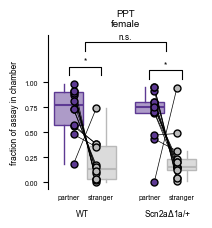

In [6]:
# ----- PLOT FEMALE CHAMBER TIME -----
sex = 'female'

typ = 'chamber'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

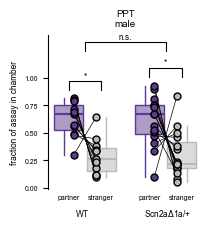

In [20]:
# ----- PLOT MALE CHAMBER TIME -----
sex = 'male'
typ = 'chamber'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [17]:
# reformat index plots
# add earthmover test to index plots
# lay out 

In [7]:
# ----- FILTER TO PPT DATA -----
# allppt = data[data['assay']=='PPT'].copy().reset_index()
# np.unique(allppt.behavior)

# ----- CALCULATE PARTNER/STRANGER CHAMBER TIMES -----
# assaydur = 3*60*60 # length of PPT in seconds

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors
phuddle = ['Huddle Partner']
shuddle = ['Huddle Stranger']

# narrow down to only huddles
phuddles = behavsums[behavsums['behavior'].isin(phuddle)].copy().reset_index(drop=True).rename(columns={"duration": "huddle_partner"})
shuddles = behavsums[behavsums['behavior'].isin(shuddle)].copy().reset_index(drop=True).rename(columns={"duration": "huddle_stranger"})

# combine
huddle=phuddles.merge(shuddles,on='pair_tag',how='outer').drop(labels=['GT_y','sex_y','behavior_y',
                                                                       'behavior_x'],axis=1).rename(columns={'GT_x': 'GT', 'sex_x': 'sex'}).fillna(0)

# calculate fractions
huddle['fraction_partner'] = huddle['huddle_partner']/assaydur
huddle['fraction_stranger'] = huddle['huddle_stranger']/assaydur

# calculate preference index
huddle['preference_index'] = (huddle['huddle_partner']-huddle['huddle_stranger'])/(huddle['huddle_partner']+huddle['huddle_stranger'])

# fix missing metadata
huddle.loc[17,'GT']='Het'
huddle.loc[17,'sex']='F'

huddle

,pair_tag,GT,sex,huddle_partner,huddle_stranger,fraction_partner,fraction_stranger,preference_index
0,Pair1,Het,F,2503.422,0.000,0.231798,0.000000,1.000000
1,Pair15,Het,F,6924.177,325.860,0.641127,0.030172,0.910108
2,Pair16,WT,F,8337.018,11.251,0.771946,0.001042,0.997305
3,Pair17,Het,M,3583.733,141.490,0.331827,0.013101,0.924037
4,Pair18,WT,M,3878.976,613.914,0.359164,0.056844,0.726718
5,Pair19,WT,M,1384.563,463.983,0.128200,0.042961,0.498002
6,Pair2,WT,F,5013.233,1755.192,0.464188,0.162518,0.481359
7,Pair21,Het,F,6814.198,150.324,0.630944,0.013919,0.956831
8,Pair22,Het,F,3887.041,36.732,0.359911,0.003401,0.981277
9,Pair23,Het,F,5739.463,42.741,0.531432,0.003958,0.985216


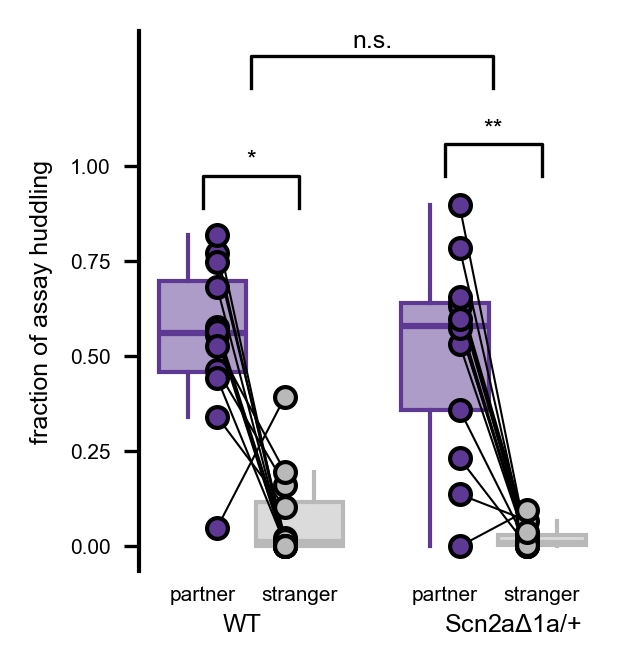

In [55]:
# ----- PLOT FEMALE HUDDLE TIME -----

figsz = (2,2) # total size of figure

sex = 'female'

typ = 'huddle'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'huddle':
    typ_str = 'huddling'
    stat = 'huddle time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
# ax.set_title(ttl)
fig.text(0.375, -0.025, 'WT', ha='center',size=6)
fig.text(0.825, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

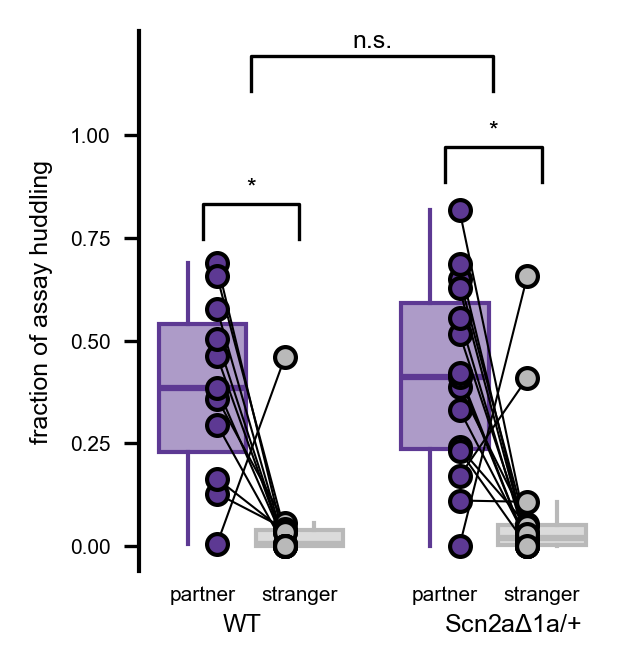

In [57]:
# ----- PLOT MALE HUDDLE TIME -----

sex = 'male'

typ = 'huddle'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'huddle':
    typ_str = 'huddling'
    stat = 'huddle time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
# ax.set_title(ttl)
fig.text(0.375, -0.025, 'WT', ha='center',size=6)
fig.text(0.825, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [24]:
# ----- FILTER TO INTERACTION DATA -----

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors
phuddle = ['Interact Partner']
shuddle = ['Interact Stranger']

# narrow down to only huddles
phuddles = behavsums[behavsums['behavior'].isin(phuddle)].copy().reset_index(drop=True).rename(columns={"duration": "interact_partner"})
shuddles = behavsums[behavsums['behavior'].isin(shuddle)].copy().reset_index(drop=True).rename(columns={"duration": "interact_stranger"})

# combine
interact=phuddles.merge(shuddles,on='pair_tag',how='outer').drop(labels=['GT_y','sex_y','behavior_y',
                                                                       'behavior_x'],axis=1).rename(columns={'GT_x': 'GT', 'sex_x': 'sex'}).fillna(0)

# calculate fractions
interact['fraction_partner'] = interact['interact_partner']/assaydur
interact['fraction_stranger'] = interact['interact_stranger']/assaydur

# calculate preference index
interact['preference_index'] = (interact['interact_partner']-interact['interact_stranger'])/(interact['interact_partner']+interact['interact_stranger'])

interact

,pair_tag,GT,sex,interact_partner,interact_stranger,fraction_partner,fraction_stranger,preference_index
0,Pair1,Het,F,207.904,5.500,0.019250,0.000509,0.948455
1,Pair15,Het,F,231.231,284.975,0.021410,0.026387,-0.104113
2,Pair16,WT,F,158.851,92.355,0.014708,0.008551,0.264707
3,Pair17,Het,M,312.092,33.990,0.028897,0.003147,0.803573
4,Pair18,WT,M,384.763,333.412,0.035626,0.030871,0.071502
5,Pair19,WT,M,222.084,351.941,0.020563,0.032587,-0.226222
6,Pair2,WT,F,209.960,214.162,0.019441,0.019830,-0.009908
7,Pair21,Het,F,155.715,92.135,0.014418,0.008531,0.256526
8,Pair22,Het,F,443.118,47.971,0.041029,0.004442,0.804634
9,Pair23,Het,F,207.180,170.149,0.019183,0.015755,0.098140


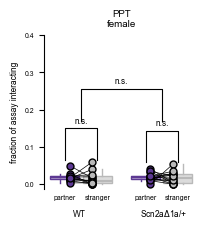

In [29]:
# ----- PLOT FEMALE INTERACT TIME -----
sex = 'female'

typ = 'interact'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = interact[interact['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

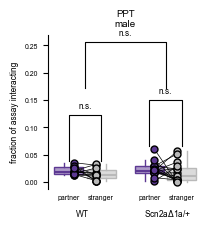

In [31]:
# ----- PLOT FEMALE INTERACT TIME -----
sex = 'male'

typ = 'interact'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = interact[interact['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'fraction of assay {typ_str}'
ttl = f'PPT\n{sex}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

# do non parametric tests


# process pvalues into text
tabw['diff'] = tabw.fraction_partner-tabw.fraction_stranger
groupstat = scipy.stats.mannwhitneyu(tabw[tabw['GT']=='WT']['diff'],tabw[tabw['GT']=='Het']['diff'])
gtp_text = decide_pval_text(groupstat[1],0.05)

# handle colors
pcol = partnercol.tolist()
scol = strangercol.tolist()

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,whiskpos,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
partnerp = scipy.stats.wilcoxon(df.fraction_partner,y=df.fraction_stranger)
partnerp_text = decide_pval_text(partnerp[1],0.05)
add_pair_to_plot_box(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)


# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
# ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

In [10]:
def plot_group_PPIs(df,ax,wtcol,hetcol,startx,dotdist,errdist,psdist,whiskpos,ptxt):

    statkey = 'preference_index'
    df['jitter'] = np.random.normal(loc=0, scale=dotdist*0.5, size=df.shape[0])

    # -- WT --
    tcol = wtcol

    tdf = df[df['GT']=='WT']
   
    # plot WT dots
    ax.plot(np.zeros(tdf.shape[0])+startx+dotdist+tdf.jitter, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot WT boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(tdf[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- STRANGER --    
    tcol = hetcol
    tdf = df[df['GT']=='Het']
    
    # plot het dots
    ax.plot(np.zeros(tdf.shape[0])+startx+psdist-dotdist+tdf.jitter, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(tdf[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    mx = np.max(df.preference_index)
    y, h = mx + ppad*mx, ppad
    px1 = startx
    px2 = startx+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

In [63]:
figsz = (1.25,2) # total size of figure

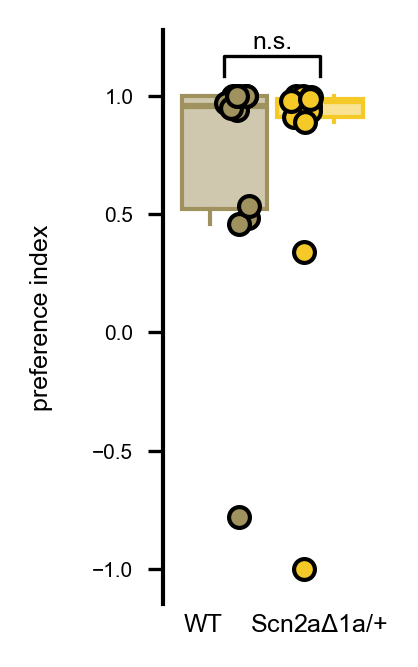

In [65]:
# ----- PLOT FEMALE HUDDLE PPIS -----

sex = 'female'

typ = 'PPI-huddle'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'PPI-huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tdf = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)


lbls = ['partner','stranger']*2
xlab = ''
ylab = f'preference index'
ttl = f'PPT\n{sex}'

partnerp_text = 'n.s.'

# make figure
fig, ax = plt.subplots(figsize=figsz)

plot_group_PPIs(tdf,ax,cols[0],cols[1],start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
# ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
# ax.set_xticks([start+psdist+gtdist,start+psdist+gtdist+psdist],labels=['WT','Scn2a$ \Delta $1a/+'])
ax.set_xticks([])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.yaxis.set_label_coords(-0.5,0.5)
# ax.set_title(ttl)
ax.set_ylim(-1.15,1.28)
fig.text(0.49, -0.025, 'WT', ha='center',size=6)
fig.text(0.8, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [19]:
ax.get_ylim()

(np.float64(-1.1085), np.float64(1.2785))

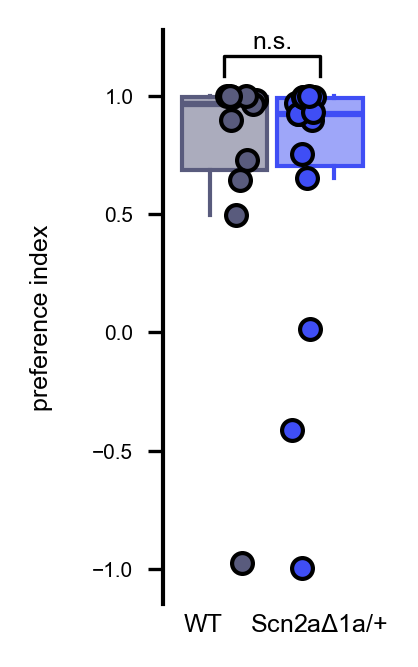

In [67]:
# ----- PLOT MALE HUDDLE PPIS -----

sex = 'male'

typ = 'PPI-huddle'

if typ == 'chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'PPI-huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tdf = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'preference index'
ttl = f'PPT\n{sex}'

partnerp_text = 'n.s.'

# make figure
fig, ax = plt.subplots(figsize=figsz)

plot_group_PPIs(tdf,ax,cols[0],cols[1],start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
# ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
# ax.set_xticks([start+psdist+gtdist,start+psdist+gtdist+psdist],labels=['WT','Scn2a$ \Delta $1a/+'])
ax.set_xticks([])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.yaxis.set_label_coords(-0.5,0.5)
# ax.set_title(ttl)
ax.set_ylim(-1.15,1.28)
fig.text(0.49, -0.025, 'WT', ha='center',size=6)
fig.text(0.8, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(os.path.join(outdir,fname),bbox_inches='tight')

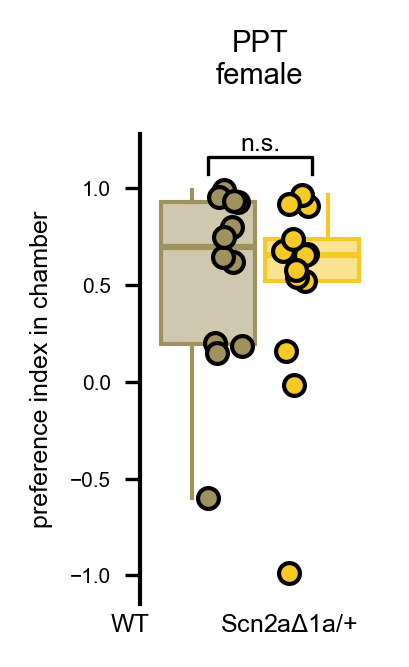

In [68]:
# ----- PLOT FEMALE CHAMBER PPIS -----

sex = 'female'

typ = 'PPI-chamber'

if typ == 'PPI-chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'PPI-huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tdf = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)

lbls = ['partner','stranger']*2
xlab = ''
ylab = f'preference index {typ_str}'
ttl = f'PPT\n{sex}'

partnerp_text = 'n.s.'

# make figure
fig, ax = plt.subplots(figsize=figsz)

plot_group_PPIs(tdf,ax,cols[0],cols[1],start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
# ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
# ax.set_xticks([start+psdist+gtdist,start+psdist+gtdist+psdist],labels=['WT','Scn2a$ \Delta $1a/+'])
ax.set_xticks([])
ax.tick_params(axis='x', which='both',length=0)
ax.set_ylim(-1.15,1.28)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

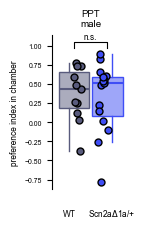

In [69]:
# ----- PLOT MALE CHAMBER PPIS -----

sex = 'male'

typ = 'PPI-chamber'

if typ == 'PPI-chamber':
    typ_str = 'in chamber'
    stat = 'chamber time'
elif typ == 'PPI-huddle':
    typ_str = 'huddling'
    stat = 'huddle time'
elif typ == 'interact':
    typ_str = 'interacting'
    stat = 'interaction time'

fname = f'PPT_{typ}_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tdf = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)


lbls = ['partner','stranger']*2
xlab = ''
ylab = f'preference index {typ_str}'
ttl = f'PPT\n{sex}'

partnerp_text = 'n.s.'

# make figure
fig, ax = plt.subplots(figsize=figsz)

plot_group_PPIs(tdf,ax,cols[0],cols[1],start+psdist+gtdist,dotdist,errdist,psdist,whiskpos,partnerp_text)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
# ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
# ax.set_xticks([start+psdist+gtdist,start+psdist+gtdist+psdist],labels=['WT','Scn2a$ \Delta $1a/+'])
ax.set_xticks([])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

In [ ]:
# consolidate/update plotting parameters
# add prefers partner/perfers stranger annotation
# update labels
# make a legend plot